## 11.11. Learning Rate Scheduler

### 11.11.1. A simple Problem

In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.optim import lr_scheduler
from d2l import torch as d2l

In [2]:
def net_fn():
  model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
  )
  
  return model

loss = nn.CrossEntropyLoss()
device = d2l.try_gpu()

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

# almost the same as d2l.train_ch6 defines at CNN LeNet
def train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler=None):
  net.to(device)
  animator = d2l.Animator(xlabel='epoch', xlim=[0, num_epochs],
                          legend=['train loss', 'train acc', 'test acc'])
  for epoch in range(num_epochs):
    metric = d2l.Accumulator(3) # tran_loss, tran_acc, num_examples
    for i, (X, y) in enumerate(train_iter):
      net.train()
      trainer.zero_grad()
      X, y = X.to(device), y.to(device)
      y_hat = net(X)
      l = loss(y_hat, y)
      l.backward()
      trainer.step()
      with torch.no_grad():
        metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
      train_loss = metric[0] / metric[2]
      train_acc = metric[1] / metric[2]
      if (i + 1) % 50 == 0:
        animator.add(epoch + i / len(train_iter), 
                      (train_loss, train_acc, None))
    test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
    animator.add(epoch+1, (None, None, test_acc))
    
    if scheduler: 
      if scheduler.__module__ == lr_scheduler.__name__:
        # Using PyTorch in-built scheduler
        scheduler.step()
      else:
        # Using customed defined scheduler
        for param_group in trainer.param_groups:
          param_group['lr'] = scheduler(epoch)
  print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
        f'test acc {test_acc:.3f}')

100.0%


Extracting ../data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%

Extracting ../data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



train loss 0.160, train acc 0.939, test acc 0.889


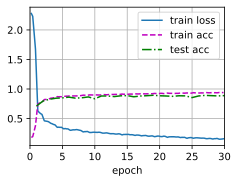

In [3]:
lr, num_epochs = 0.3, 30
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device)

### 11.11.2. Learning Rate Schedule

In [5]:
lr = 0.1
trainer.param_groups[0]["lr"] = lr
print(f'learning rate is now {trainer.param_groups[0]["lr"]:.2f}')

learning rate is now 0.10


In [6]:
class SquareRootScheduler:
  def __init__(self, lr=0.1):
    self.lr = lr
  def __call__(self, num_update):
    return self.lr * pow(num_update + 1.0, -0.5)

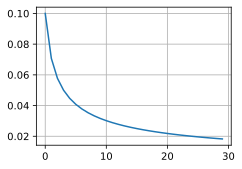

In [7]:
scheduler = SquareRootScheduler(lr=0.1)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

train loss 0.269, train acc 0.902, test acc 0.882


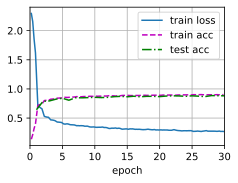

In [8]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

### 11.11.3 Strategy

#### 11.11.3.1 Single Factor Scheduler

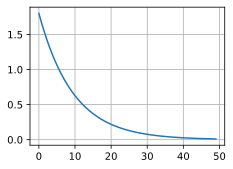

In [9]:
class FactorScheduler:
  def __init__(self, factor=1, stop_factor_lr=1e-7, base_lr=0.1):
    self.factor = factor
    self.stop_factor_lr = stop_factor_lr
    self.base_lr = base_lr
    
  def __call__(self, num_update):
    self.base_lr = max(self.stop_factor_lr, self.base_lr * self.factor)
    return self.base_lr
  
scheduler = FactorScheduler(factor=0.9, stop_factor_lr=1e-2, base_lr=2.0)
d2l.plot(torch.arange(50), [scheduler(t) for t in range(50)])

#### 11.11.3.2. Multi Factor Scheduler

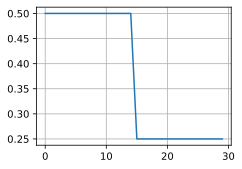

In [10]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
scheduler = lr_scheduler.MultiStepLR(trainer, milestones=[15, 30], gamma=0.5)

def get_lr(trainter, scheduler):
  lr = scheduler.get_last_lr()[0]
  trainer.step()
  scheduler.step()
  return lr

d2l.plot(torch.arange(num_epochs), [get_lr(trainer, scheduler) for t in range(num_epochs)])

train loss 0.199, train acc 0.925, test acc 0.898


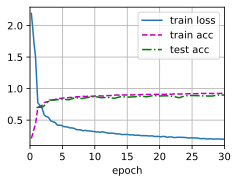

In [11]:
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

#### 11.11.3.3. Cosine Scheduler

$$
\eta_t = η_T + \frac{η_0 + η_T}2(1 + \cos(πt/T))
$$

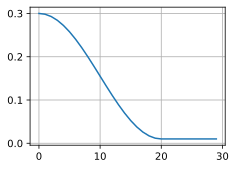

In [12]:
class CosineScheduler:
  def __init__(self, max_update, base_lr=0.01, final_lr=0,
              warmup_steps=0, warmup_begin_lr=0):
    self.base_lr_orig = base_lr
    self.max_update = max_update
    self.final_lr = final_lr
    self.warmup_steps = warmup_steps
    self.warmup_begin_lr = warmup_begin_lr
    self.max_steps = self.max_update - self.warmup_steps
    
  def get_warmup_lr(self, epoch):
    increase = (self.base_lr_orig - self.warmup_begin_lr) \
      * float(epoch) / float(self.warmup_steps)
    return self.warmup_begin_lr + increase
  
  def __call__(self, epoch):
    if epoch < self.warmup_steps:
      return self.get_warmup_lr(epoch)
    if epoch <= self.max_update:
      self.base_lr = self.final_lr + (
        self.base_lr_orig - self.final_lr
      ) * (1 + math.cos(
        math.pi * (epoch - self.warmup_steps) / self.max_steps
      )) / 2
    return self.base_lr
  
scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

train loss 0.186, train acc 0.932, test acc 0.903


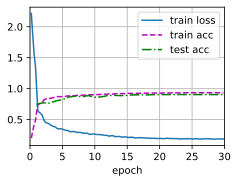

In [13]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.3)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

#### 11.11.3.4. WarmUp

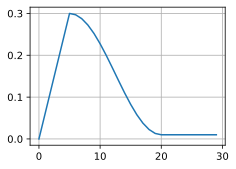

In [14]:
scheduler = CosineScheduler(20, warmup_steps=5, base_lr=0.3, final_lr=0.01)
d2l.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

train loss 0.175, train acc 0.935, test acc 0.905


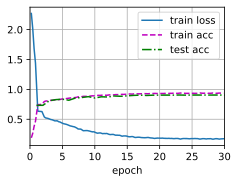

In [15]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.3)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)